# 🛏️ PSG Sleep Stage Classification Pipeline
**Subject:** SN1 | **Scorer:** Scorer 1 | **Dataset:** PSG-IPA v1.0.0

## Step 1: Load EDF and Convert to DataFrame

### 💡 Concept
- **EDF (European Data Format)** is the hospital standard for storing biosignals (EEG, EMG, ECG, SpO₂ etc.).
- `mne.io.read_raw_edf` reads the binary EDF file and gives us a `Raw` object with all 13 channels.
- `raw.to_data_frame()` unpacks that into a Pandas table where each **column = 1 sensor** and each **row = 1 time point** (at 256 Hz → 6,922,752 rows total).
- We import all libraries upfront here (`mne`, `pandas`, `numpy`, `matplotlib`) so they are available across every cell below.

### 🔍 Output — `df.head()`
| Column | Sensor Type | Clinical Role |
|---|---|---|
| `EEG F4-M1`, `Cz-M1`, `O2-M1` | Scalp electrodes | Brainwave activity (µV) |
| `EMG chin` | Chin muscle | Muscle atonia (goes flat in REM) |
| `EOG E1-M2`, `E2-M2` | Eye sensors | Rapid eye movements (detect REM) |
| `ECG` | Heart | Heart rate & autonomic arousals |
| `EMG LAT`, `RAT` | Leg muscles | Periodic Limb Movement Detection |
| `Resp nasal`, `abdomen`, `chest` | Breathing | Airflow & respiratory effort |
| `SaO2` | Pulse oximeter | Blood oxygen % |

In [1]:
import mne                        # reads EDF biosignal files
import pandas as pd               # tabular data manipulation
import numpy as np                # numerical array operations
import matplotlib.pyplot as plt   # plotting (used in later steps)

# relative path works because we set up a symlink in the project root
file_path = "Sleep_stages/PSG/SN1_SleepStages.edf"

# preload=True loads all signal data into RAM upfront (faster for later access)
raw = mne.io.read_raw_edf(file_path, preload=True)

# converts the Raw MNE object → Pandas DataFrame (rows=time points, cols=channels)
df = raw.to_data_frame()

Extracting EDF parameters from Sleep_stages/PSG/SN1_SleepStages.edf...
Setting channel info structure...
Creating raw.info structure...


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_29137/1947214491.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_29137/1947214491.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)


Reading 0 ... 6922751  =      0.000 ... 27041.996 secs...


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_91331/1947214491.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_91331/1947214491.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)


## Step 2: Select EEG and Create 30-Second Epochs

### 💡 Concept
- **AASM standard**: Sleep scoring always uses 30-second windows called **epochs**.
- We pick `EEG Cz-M1` (central vertex electrode) — the most informative single channel for sleep staging.
- `sfreq = 256` Hz → each second has 256 data points → each 30-sec epoch has **7,680 samples**.
- `.iloc[:len(eeg) // epoch_size * epoch_size]` trims any leftover samples that don't fill a complete epoch (avoids reshape errors).
- `.reshape(-1, epoch_size)` cuts the long 1D signal into a 2D array: **rows = epochs, columns = samples within an epoch**.

### 🔍 Output — `epochs.shape`
```
(901, 7680)
```
| Dimension | Value | Meaning |
|---|---|---|
| Rows | `901` | Total 30-second epochs ≈ 7.5 hours of sleep |
| Columns | `7680` | EEG amplitude values (µV) inside each epoch |

In [2]:
# extract only the central EEG channel (AASM standard for sleep staging)
eeg = df["EEG Cz-M1"]

# sampling frequency: 256 data points recorded every second
sfreq = 256

# one 30-second epoch = 30 × 256 = 7,680 samples
epoch_size = 30 * sfreq

# trim the signal so its length is exactly divisible by epoch_size (no leftover)
eeg = eeg.iloc[:len(eeg) // epoch_size * epoch_size]

# reshape 1D signal → 2D array: shape = (number_of_epochs, samples_per_epoch)
epochs = eeg.to_numpy().reshape(-1, epoch_size)

# confirm shape: should print (901, 7680)
epochs.shape

(901, 7680)

## Step 3: Create the EEG DataFrame

### 💡 Concept
- We wrap the NumPy epochs array back into a Pandas DataFrame so we can later **merge it with labels** using `merge()`.
- `list(epochs)` converts each NumPy row (7,680 numbers) into a Python list stored in one DataFrame cell.
- This gives us a clean table: **1 row = 1 epoch = 30 seconds of EEG signal**.
- We overwrite `df` here because we no longer need the 13-channel table — from now on we work only with the EEG column.

### 🔍 Output — `df.head()`
| Index | EEG |
|---|---|
| 0 | `[-0.000123, 0.000456, ...]` (7,680 µV values) |
| 1 | `[0.000789, -0.000321, ...]` (7,680 µV values) |
| 2 | `[...]` |

Each cell in the `EEG` column is one **complete 30-second waveform**.

In [3]:
# create a new DataFrame where each row = one 30-sec epoch stored as a list
df = pd.DataFrame({
    "EEG": list(epochs)   # list(epochs) converts each numpy row → python list
})

# each row now holds 7,680 EEG amplitude values (one full epoch)
df.head()

,EEG
0,"[7.458609903105211, -13.098344396124208, -33.0..."
1,"[-387.95757991912717, -398.69993133440147, -40..."
2,"[-4.382391088731213, 1.2329289692530707, -3.89..."
3,"[22.790875104905776, 20.740062561989777, 20.49..."
4,"[2.4780651560234985, 0.18310826276035702, 0.23..."


## Step 4: Load Sleep-Stage Annotations

### 💡 Concept
- The annotation file contains a **doctor's manual scoring** — one label per 30-second epoch.
- `sep="\t"` tells pandas the file uses **tab characters** as column separators (not commas).
- `skipinitialspace=True` removes any extra spaces that appear after tab/comma characters.
- `.str.contains("Sleep stage")` keeps only rows that are actual sleep labels — this removes point-in-time events like `Lights off` and `Lights on` which have no epoch duration.
- `.str.replace("Sleep stage ", "")` strips the prefix so `"Sleep stage N2"` becomes just `"N2"` — cleaner for mapping later.

### 🔍 Output — `labels` after cleaning
| Annotation | epoch |
|---|---|
| W | 0 |
| N2 | 1 |
| N2 | 2 |
| N3 | 3 |
| R | 4 |

- `Annotation` = doctor's label for that epoch
- `epoch` = sequential epoch number (used to merge with EEG data)

In [4]:
# path to scorer 1's manual annotation file
annotation_file = "Sleep_stages/Annotations/manual/SN1_SleepStages_manual_scorer1.txt"

# read the comma-separated annotation file into a DataFrame
labels = pd.read_csv(
    annotation_file,
    sep=",",              # columns are separated by commas
    skipinitialspace=True  # remove extra whitespace after separators
)

# keep only rows that are actual sleep stage annotations (removes Lights on/off etc.)
labels = labels[
    labels["Annotation"].str.contains("Sleep stage")
].copy()

# strip the "Sleep stage " prefix → "Sleep stage N2" becomes "N2"
labels["Annotation"] = labels["Annotation"].str.replace(
    "Sleep stage ", "", regex=False
)

# keep only the annotation column (we don't need time/duration columns)
labels = labels[["Annotation"]]

# assign sequential epoch numbers (0, 1, 2, ...) matching EEG DataFrame row indices
labels["epoch"] = range(len(labels))

## Step 5: Remove Unknown `?` Labels

### 💡 Concept
- Some epochs are marked `"?"` by the doctor — this means the epoch was **ambiguous or unscoreable** (e.g., excessive artifact, unclear signal).
- We found **2 such epochs** in SN1's recording.
- We remove them because `?` cannot be mapped to any real sleep stage — including them would corrupt the label encoding in Step 6.

### 🔍 Output — after filtering
| Before | After |
|---|---|
| 903 epochs (including 2 with `?`) | **901 clean epochs** |

The remaining 901 epochs all have valid AASM labels: `W`, `N1`, `N2`, `N3`, or `R`.

In [5]:
# remove the 2 epochs where the doctor couldn't score the stage (marked "?")
labels = labels[labels["Annotation"] != "?"]

## Step 6: Convert Sleep Stages to Numbers

### 💡 Concept
- Machine learning models work with **numbers, not strings** — we must encode the stage labels.
- We use the AASM standard numeric mapping:

| Stage | Code | Clinical Meaning |
|---|---|---|
| `W` | `0` | **Wake** — eyes open, alpha waves |
| `N1` | `1` | **Drowsy** — light sleep, theta waves, slow eye rolls |
| `N2` | `2` | **Core sleep** — sleep spindles & K-complexes |
| `N3` | `3` | **Deep/Slow-Wave sleep** — high-amplitude delta waves |
| `R` | `4` | **REM** — dreaming, rapid eye movements, muscle atonia |

- We also create a human-readable `stage` column alongside `label` so we can display results clearly without remembering the numeric codes.

In [6]:
# map stage string → numeric label (ML models need numbers not text)
labels["label"] = labels["Annotation"].map({
    "W":  0,   # Wake
    "N1": 1,   # Non-REM stage 1 (drowsy/light)
    "N2": 2,   # Non-REM stage 2 (core sleep)
    "N3": 3,   # Non-REM stage 3 (deep slow-wave sleep)
    "R":  4    # REM (dreaming)
})

# also keep a readable stage name column for reports and plots
labels["stage"] = labels["label"].map({
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
})

## Step 7: Combine EEG Epochs with Labels

### 💡 Concept
- `df["epoch"] = df.index` adds an epoch number column to the EEG DataFrame so both tables share a common key.
- `merge(..., on="epoch", how="inner")` joins the EEG and labels tables — only keeping epochs that exist in **both** (inner join removes the 2 dropped `?` epochs automatically).
- After merging, each row has: the raw EEG waveform **AND** its doctor-assigned sleep stage.

### 🔍 Output — `df.head()`
| epoch | EEG | label | stage |
|---|---|---|---|
| 0 | `[...7680 values...]` | 0 | Wake |
| 1 | `[...7680 values...]` | 2 | N2 |
| 2 | `[...7680 values...]` | 2 | N2 |
| 3 | `[...7680 values...]` | 3 | N3 |
| 4 | `[...7680 values...]` | 4 | REM |

In [7]:
# add epoch number to EEG df so we can merge on it (df.index = 0, 1, 2, ...)
df["epoch"] = df.index

# inner join: keeps only epochs that appear in BOTH df and labels
# (automatically drops the 2 ? epochs we removed from labels)
df = df.merge(
    labels[["epoch", "label", "stage"]],  # bring in label + stage columns
    on="epoch",                            # match rows by epoch number
    how="inner"                            # only keep matching rows
)

# confirm the result: should show epoch | EEG | label | stage columns
df.head()

,EEG,epoch,label,stage
0,"[-4.382391088731213, 1.2329289692530707, -3.89...",2,0,Wake
1,"[22.790875104905776, 20.740062561989777, 20.49...",3,0,Wake
2,"[2.4780651560234985, 0.18310826276035702, 0.23...",4,0,Wake
3,"[15.100328068970777, 18.78690775921263, 21.008...",5,0,Wake
4,"[13.562218661783778, 13.684290836957349, 14.22...",6,0,Wake


## Step 8: Check Class Distribution

### 💡 Concept
- **Class imbalance** is a critical problem in sleep staging — healthy humans spend very little time in N1 or Wake compared to N2.
- If we train a model on imbalanced data it will be **biased toward N2** (the majority class) and completely fail to detect rare but clinically important stages like N1 and Wake.
- We must understand the imbalance before modeling so we can choose a fix (class weights, oversampling, or Focal Loss).

### 🔍 Expected Output
| Stage | Count | % of Total | Clinical Note |
|---|---|---|---|
| `N2` | ~475 | ~53% | Core sleep dominates |
| `REM` | ~172 | ~19% | Dreaming sleep |
| `N3` | ~159 | ~18% | Deep restorative sleep |
| `N1` | ~47 | ~5% | Very brief transitional stage |
| `Wake` | ~46 | ~5% | Brief awakening periods |

> ⚠️ **N2 is 10× more frequent than Wake/N1** — a naive model will mostly predict N2 and get ~53% accuracy while being clinically useless.

In [8]:
# count how many epochs belong to each sleep stage
# this reveals class imbalance — critical for choosing the right ML strategy
df["stage"].value_counts()

stage
N2      475
REM     172
N3      159
N1       47
Wake     46
Name: count, dtype: int64

## Step 9: Create Frequency-Domain Features

### 💡 Concept
- The brain produces different **frequency patterns** in each sleep stage — this is the core clinical insight of EEG-based sleep scoring.
- **Welch's method** (`welch()`) computes the **Power Spectral Density (PSD)** — how much signal energy exists at each frequency.
  - `nperseg=1024` = window size (4 seconds × 256 Hz) for frequency resolution.
  - `f` = array of frequency values (Hz), `power` = energy at each frequency (µV²/Hz).
- We sum the power in 4 clinical frequency bands:

| Feature | Band | High in Stage | Why? |
|---|---|---|---|
| `delta` | 0.5–4 Hz | **N3** | Slow-wave sleep generates large, slow delta waves |
| `theta` | 4–8 Hz | **N1/REM** | Drowsiness and REM background rhythm |
| `alpha` | 8–13 Hz | **Wake** | Relaxed wakefulness with eyes closed |
| `beta` | 13–30 Hz | **Wake/arousal** | Active thinking, micro-arousals |
| `total` | sum | — | Total power (normalization denominator) |
| `delta_rel` | delta/total | **N3** | **Relative power** — removes amplitude differences between subjects |
| `theta_rel` | theta/total | **N1** | Proportion of theta energy |
| `alpha_rel` | alpha/total | **Wake** | Proportion of alpha energy |
| `beta_rel` | beta/total | **Wake** | Proportion of beta energy |

In [9]:
from scipy.signal import welch   # Welch's method for power spectral density

features = []   # will hold one feature dictionary per epoch

for signal in df["EEG"]:   # iterate over each 30-sec EEG epoch

    # compute PSD: f = frequencies (Hz), power = energy at each frequency
    f, power = welch(signal, fs=256, nperseg=1024)

    # sum power in each clinical frequency band
    delta = power[(f >= 0.5) & (f < 4)].sum()    # 0.5–4 Hz: slow-wave sleep
    theta = power[(f >= 4) & (f < 8)].sum()      # 4–8 Hz: drowsy / REM
    alpha = power[(f >= 8) & (f < 13)].sum()     # 8–13 Hz: relaxed wake
    beta  = power[(f >= 13) & (f < 30)].sum()    # 13–30 Hz: alert / arousal

    # total band power (used to compute relative/normalized features)
    total = delta + theta + alpha + beta

    # store absolute AND relative (normalized) band powers
    features.append([
        delta,          # raw delta power
        theta,          # raw theta power
        alpha,          # raw alpha power
        beta,           # raw beta power
        total,          # sum of all band powers
        delta / total,  # delta as fraction of total (relative power)
        theta / total,  # theta as fraction of total
        alpha / total,  # alpha as fraction of total
        beta  / total   # beta as fraction of total
    ])

# convert list of feature lists → DataFrame with named columns
features_df = pd.DataFrame(
    features,
    columns=[
        "delta",      # absolute delta power
        "theta",      # absolute theta power
        "alpha",      # absolute alpha power
        "beta",       # absolute beta power
        "total",      # total band power
        "delta_rel",  # relative delta (fraction)
        "theta_rel",  # relative theta (fraction)
        "alpha_rel",  # relative alpha (fraction)
        "beta_rel"    # relative beta (fraction)
    ]
)

# attach labels to the feature DataFrame (same row order as df)
features_df["label"] = df["label"].values   # numeric label (0–4)
features_df["stage"] = df["stage"].values   # readable stage name

## Step 10: Add Time-Domain Features

### 💡 Concept
- Frequency features capture **what rhythms** are present; time-domain features capture **how energetic or variable** the signal is.
- These are simpler statistics computed directly on the raw amplitude values of each epoch:

| Feature | Formula | High Value Means |
|---|---|---|
| `mean` | $\bar{x} = \frac{1}{N}\sum x_i$ | Signal DC offset (usually ≈ 0 for EEG) |
| `std` | $\sigma = \sqrt{\frac{1}{N}\sum(x_i - \bar{x})^2}$ | High variability → **Wake or N3** |
| `min` | $\min(x_i)$ | Most negative amplitude in epoch |
| `max` | $\max(x_i)$ | Most positive amplitude in epoch |
| `rms` | $\sqrt{\frac{1}{N}\sum x_i^2}$ | Signal energy — high in **Wake & N3** |
| `range` | $\max - \min$ | Peak-to-peak amplitude — large in **N3** (big slow waves) |

> **Key observation:** `std` and `rms` together give strong Wake vs. Sleep separation — Wake has **high, irregular amplitude**; N2 has **moderate, rhythmic amplitude**.

In [10]:
# average amplitude of the epoch (EEG is AC-coupled so this ≈ 0)
features_df["mean"] = df["EEG"].apply(np.mean)

# standard deviation — measures signal variability / amplitude spread
features_df["std"] = df["EEG"].apply(np.std)

# minimum amplitude value in the epoch (most negative peak)
features_df["min"] = df["EEG"].apply(np.min)

# maximum amplitude value in the epoch (most positive peak)
features_df["max"] = df["EEG"].apply(np.max)

# root mean square — overall signal energy (similar to std but always positive)
features_df["rms"] = df["EEG"].apply(
    lambda x: np.sqrt(np.mean(np.array(x) ** 2))
)

# peak-to-peak range = max − min (large in N3 due to big delta waves)
features_df["range"] = (
    features_df["max"] - features_df["min"]
)

## Step 11: Final Feature Table

### 💡 Summary of All Features
We now have **15 features per epoch** that will be used to train our sleep stage classifier:

| # | Feature | Type | Captures |
|---|---|---|---|
| 1 | `delta` | Frequency | Absolute slow-wave power |
| 2 | `theta` | Frequency | Absolute drowsy/REM power |
| 3 | `alpha` | Frequency | Absolute wake-relaxed power |
| 4 | `beta` | Frequency | Absolute alert/arousal power |
| 5 | `total` | Frequency | Total band power (normalization) |
| 6 | `delta_rel` | Frequency | Relative delta fraction |
| 7 | `theta_rel` | Frequency | Relative theta fraction |
| 8 | `alpha_rel` | Frequency | Relative alpha fraction |
| 9 | `beta_rel` | Frequency | Relative beta fraction |
| 10 | `mean` | Time | DC offset |
| 11 | `std` | Time | Signal variability |
| 12 | `min` | Time | Most negative peak |
| 13 | `max` | Time | Most positive peak |
| 14 | `rms` | Time | Signal energy |
| 15 | `range` | Time | Peak-to-peak amplitude |
| — | `label` | Target | Numeric class (0–4) |
| — | `stage` | Target | Readable name (Wake/N1/N2/N3/REM) |

In [11]:
# display the final feature table — each row = one 30-sec epoch with 15 features + label
features_df.head()

,delta,theta,alpha,beta,total,delta_rel,theta_rel,alpha_rel,beta_rel,label,stage,mean,std,min,max,rms,range
0,26083.878496,226.171686,136.023216,262.675284,26708.748682,0.976604,0.008468,0.005093,0.009835,0,Wake,3.284838,120.410132,-407.220569,462.201877,120.454929,869.422446
1,4771.860465,59.609655,44.184675,62.516285,4938.171080,0.966321,0.012071,0.008948,0.012660,0,Wake,2.764080,41.526172,-114.125277,125.795377,41.618062,239.920653
2,1124.410908,63.720101,36.232907,39.063653,1263.427569,0.889969,0.050434,0.028678,0.030919,0,Wake,4.520339,19.999912,-82.044709,83.094530,20.504388,165.139239
3,884.666591,40.096641,33.241625,59.445883,1017.450740,0.869493,0.039409,0.032671,0.058426,0,Wake,4.431118,21.111144,-81.702907,88.368048,21.571166,170.070954
4,1252.747478,54.254968,37.057074,50.211645,1394.271166,0.898496,0.038913,0.026578,0.036013,0,Wake,4.169715,26.215360,-102.723735,109.217975,26.544898,211.941711


## Step 12: Key Observations So Far

After building the full feature table, we have found two important patterns:

### 🔑 Observation 1 — `std` + `rms` separate Wake from Sleep

```
std + RMS
     ↓
strong separation of Wake from most sleep stages
```

| Stage | std / rms | Why |
|---|---|---|
| **Wake** | High | Brain is active → irregular, high-amplitude EEG |
| **N2** | Medium | Rhythmic spindles → more regular, lower amplitude |
| **N3** | High | Big delta waves push amplitude up |
| **REM** | Low–Medium | Mixed frequency, lower overall amplitude |

---

### 🔑 Observation 2 — Delta / Theta / Alpha / Beta distinguish sleep stages

```
Delta / Theta / Alpha / Beta
     ↓
help distinguish the different sleep stages
```

| Feature | Highest in | Why |
|---|---|---|
| `delta_rel` | **N3** | Slow-wave sleep is defined by >20% delta dominance |
| `theta_rel` | **N1 / REM** | Theta rhythm dominates drowsiness and dreaming |
| `alpha_rel` | **Wake** | Alpha = relaxed wakefulness signature |
| `beta_rel` | **Wake** | Beta = alertness and arousal |

---

> **Next step:** Use these 15 features as input (`X`) to train a classifier (`y = label`) — e.g. Random Forest, LightGBM, or SVM — and evaluate with Cohen's Kappa score.

---
# 📊 Visualization — Understanding the Signal Before ML

We follow this flow before building the model:

```
Raw EEG waveform  →  Spectrogram  →  Power Spectrum
      ↓                                    ↓
Understand signal          Compare frequency patterns across stages
                                           ↓
                       Delta/Theta/Alpha/Beta boxplots
                                           ↓
                          STD + RMS boxplots (Wake separation)
                                           ↓
                              Feature table → ML
```

## Viz 1: EEG Waveform — 5 Minutes (Epochs 100–109)

### 💡 Concept
- We concatenate 10 consecutive 30-second epochs (`iloc[100]` to `iloc[109]`) into one continuous 5-minute signal.
- `signal.extend(...)` appends each epoch's 7,680 values → total = **76,800 samples = 300 seconds**.
- `time = np.arange(len(signal)) / 256` converts sample index → seconds by dividing by the sampling rate.
- `plt.axvline(i * 30)` draws a **dashed vertical line** at every 30-second epoch boundary.

### 🔍 What You See in the Plot
| Pattern | Likely Stage |
|---|---|
| Flat, low-amplitude, regular | N2 (sleep spindles) |
| Large, slow swings every ~1–2 sec | N3 (delta waves) |
| Noisy, rapid, irregular bursts | Wake |
| Low-amplitude, mixed frequency | REM |

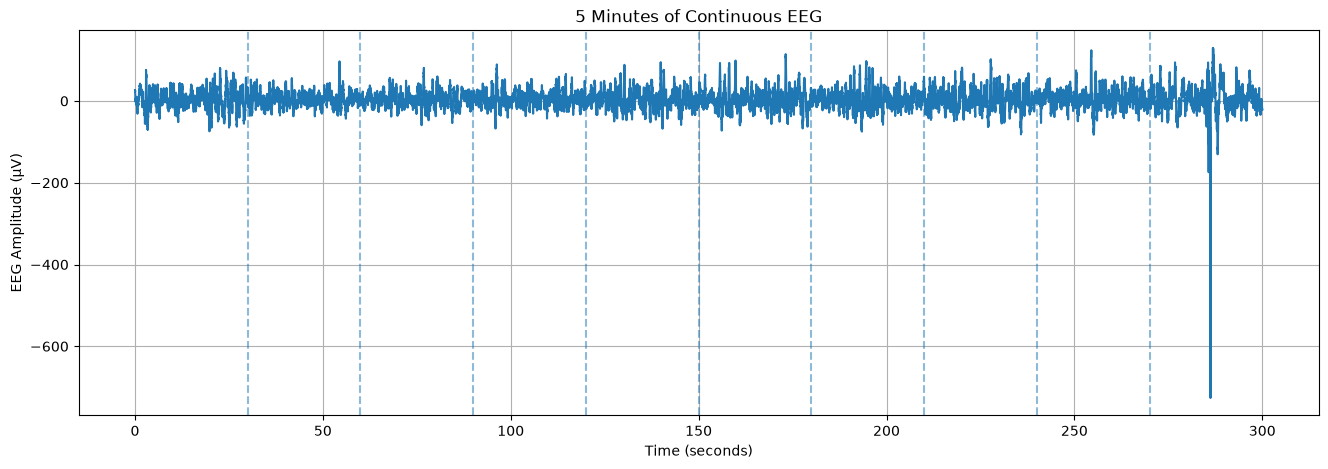

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# choose epochs 100 to 109 (10 epochs × 30 sec = 5 minutes of EEG)
start = 100
end = 110

signal = []   # will hold concatenated amplitude values from all 10 epochs

# loop through each epoch and append its 7,680 amplitude values to the list
for i in range(start, end):
    signal.extend(df["EEG"].iloc[i])   # .extend() adds values (not a nested list)

# convert Python list → NumPy array for vectorized operations
signal = np.array(signal)

# convert sample index → time in seconds (sample_number / sampling_rate)
time = np.arange(len(signal)) / 256

plt.figure(figsize=(16, 5))
plt.plot(time, signal)   # x = seconds elapsed, y = EEG amplitude in µV

# draw a dashed vertical line at each 30-second epoch boundary
for i in range(1, 10):
    plt.axvline(i * 30, linestyle="--", alpha=0.5)   # alpha=0.5 = semi-transparent

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude (µV)")
plt.title("5 Minutes of Continuous EEG")
plt.grid(True)

plt.show()

## Viz 2: EEG Spectrogram (Epoch 100)

### 💡 Concept
- A **spectrogram** is a 2D heatmap showing **frequency vs. time vs. power** within a single 30-second epoch.
- `scipy.signal.spectrogram` splits the epoch into overlapping short windows and computes PSD on each:
  - **x-axis** = time (0–30 sec inside the epoch)
  - **y-axis** = frequency (Hz), clipped to 0–30 Hz
  - **color** = power (bright = high, dark = low)
- `shading="gouraud"` smooths color transitions.

### 🔍 What You See in the Plot
| Color Location | Meaning |
|---|---|
| Bright strip at 0–4 Hz | Strong delta → likely N3 |
| Bright strip at 8–13 Hz | Alpha → Wake or N1 |
| Bright vertical bar | Transient burst (movement artifact) |
| Uniform dark | Quiet low-power sleep |

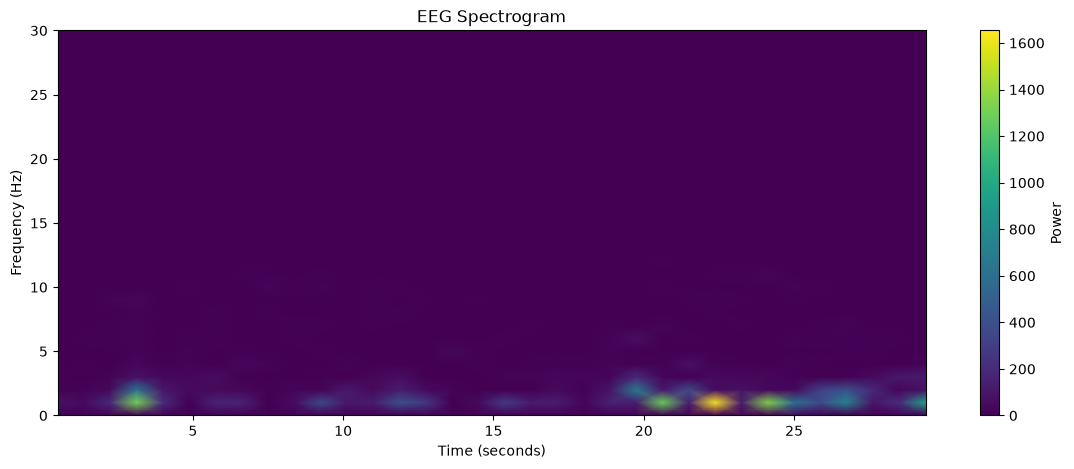

In [13]:
from scipy.signal import spectrogram

# take a single 30-second epoch (epoch index 100)
signal = df["EEG"].iloc[100]

# compute spectrogram: f=frequencies(Hz), t=time windows, power=energy at each cell
f, t, power = spectrogram(signal, fs=256)

plt.figure(figsize=(14, 5))

# render 2D color heatmap: x=time, y=frequency, color=power magnitude
plt.pcolormesh(
    t,          # x-axis: time windows within the epoch
    f,          # y-axis: frequency in Hz
    power,      # color values: power at each (time, frequency) cell
    shading="gouraud"   # smooth color interpolation between cells
)

# limit y-axis to clinically relevant 0–30 Hz range
plt.ylim(0, 30)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("EEG Spectrogram")

plt.colorbar(label="Power")   # color legend showing power scale

plt.show()

## Viz 3: Power Spectrum — All Sleep Stages Compared

### 💡 Concept
- Overlays the **Welch PSD** of one representative epoch per stage — 5 lines on one chart.
- `plt.semilogy` uses **log scale on y** because power spans orders of magnitude.
- This is the **clinical justification** for using delta/theta/alpha/beta as ML features.

### 🔍 What You See in the Plot
| Line | Expected Shape | Reason |
|---|---|---|
| **N3** | Huge spike 0–4 Hz | Large slow delta waves |
| **N1** | Moderate theta bump 4–8 Hz | Drowsy theta rhythm |
| **Wake** | Alpha peak 8–13 Hz + beta | Relaxed wakefulness |
| **REM** | Theta bump, low delta | Dreaming rhythm |
| **N2** | Moderate, relatively flat | Mixed activity |

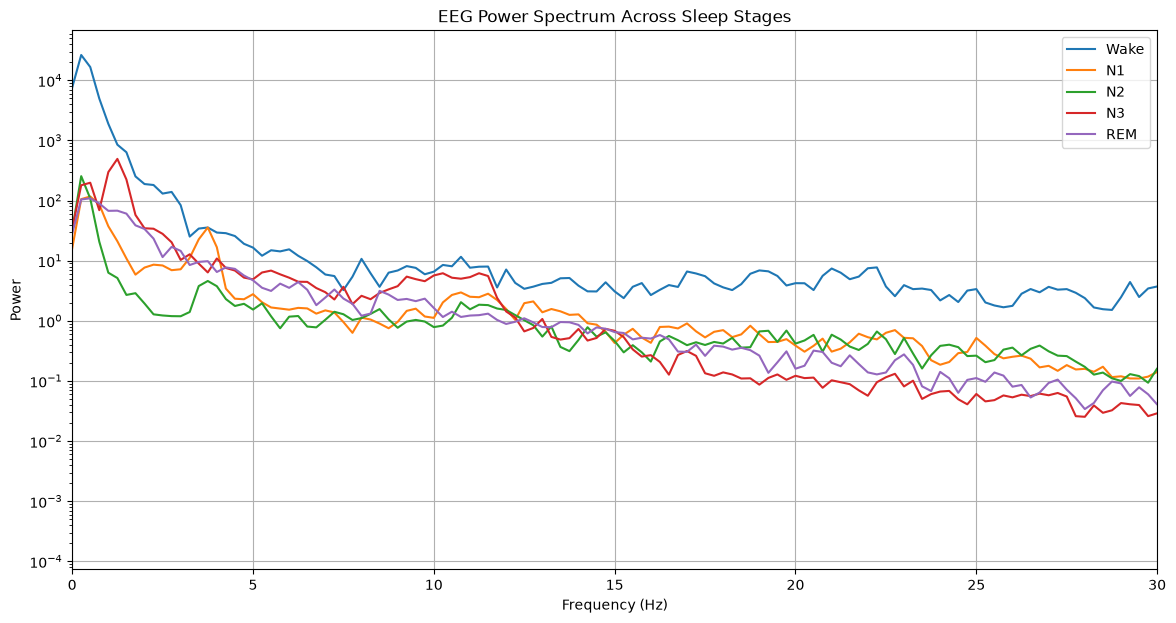

In [14]:
from scipy.signal import welch

# human-readable names for each numeric sleep stage label
names = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}

plt.figure(figsize=(14, 7))

# plot one representative epoch from each of the 5 sleep stages
for label in range(5):

    # pick the first epoch that belongs to this stage
    signal = df[df["label"] == label]["EEG"].iloc[0]

    # Welch PSD: f=frequency array, power=energy at each frequency
    f, power = welch(
        signal,
        fs=256,        # sampling rate = 256 Hz
        nperseg=1024   # window = 4 seconds → good frequency resolution
    )

    # semilogy = log scale on y-axis so all lines are visible
    plt.semilogy(
        f,
        power,
        label=names[label]   # each line labeled with stage name
    )

# restrict x-axis to clinically relevant 0–30 Hz range
plt.xlim(0, 30)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("EEG Power Spectrum Across Sleep Stages")

plt.legend()
plt.grid(True)

plt.show()

## Viz 4: Average Frequency Band Power by Stage (Bar Chart)

### 💡 Concept
- Instead of one single epoch, we **average all epochs per stage** for a robust picture.
- `groupby("label")[[cols]].mean()` computes mean delta/theta/alpha/beta per stage.
- `.plot(kind="bar")` creates a **grouped bar chart** — one cluster of 4 bars per stage.

### 🔍 What You See in the Plot
| Stage | Tallest Bar | Why |
|---|---|---|
| **Wake** | Alpha + Beta | Alert wakefulness |
| **N1** | Theta | Sleep onset rhythm |
| **N3** | Delta (very tall) | Slow-wave sleep dominance |
| **REM** | Theta | Dreaming state |

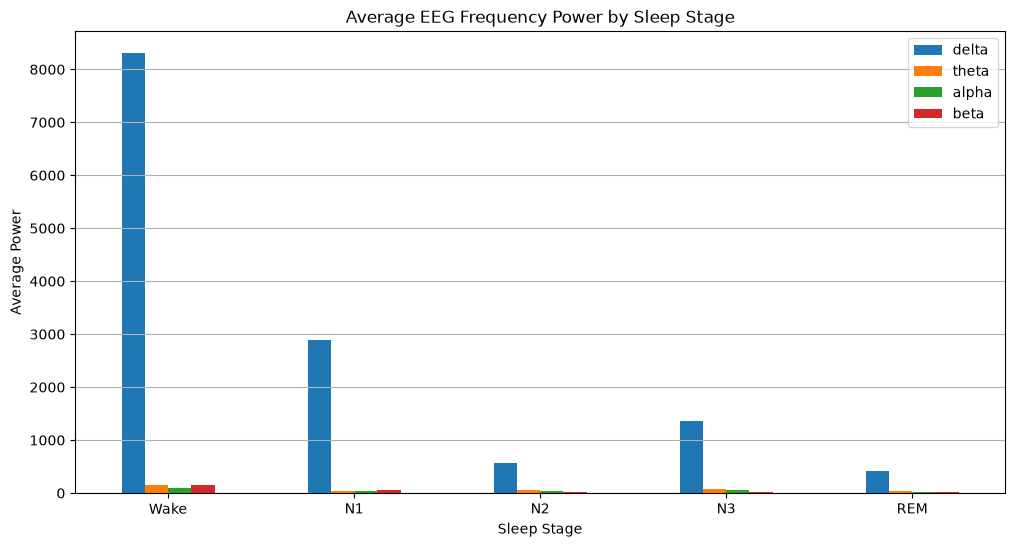

In [15]:
# compute mean of each frequency band across all epochs within each stage
average_power = features_df.groupby("label")[
    ["delta", "theta", "alpha", "beta"]   # select only the 4 band power columns
].mean()

# replace numeric index [0,1,2,3,4] → readable stage names
average_power.index = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM"
]

# grouped bar chart: each stage = one cluster of 4 bars (delta/theta/alpha/beta)
average_power.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Sleep Stage")
plt.ylabel("Average Power")
plt.title("Average EEG Frequency Power by Sleep Stage")
plt.xticks(rotation=0)   # keep stage labels horizontal (not rotated)
plt.grid(axis="y")       # horizontal gridlines only

plt.show()

## Viz 5: Relative Delta Power Boxplot

### 💡 Concept
- **Boxplot** shows full distribution across all epochs in each stage (not just the mean).
  - **Box** = middle 50%. **Line** = median. **Whiskers** = spread. **Dots** = outliers.
- `delta_rel` = delta/total — **normalized** so amplitude differences between subjects don't matter.

### 🔍 What You See in the Plot
| Stage | delta_rel | Interpretation |
|---|---|---|
| **N3** | High (~0.6–0.8) | Deep sleep defined by delta dominance |
| **N2** | Medium | Some slow waves, not fully dominant |
| **Wake / REM / N1** | Low | Fast rhythms dominate — little delta |

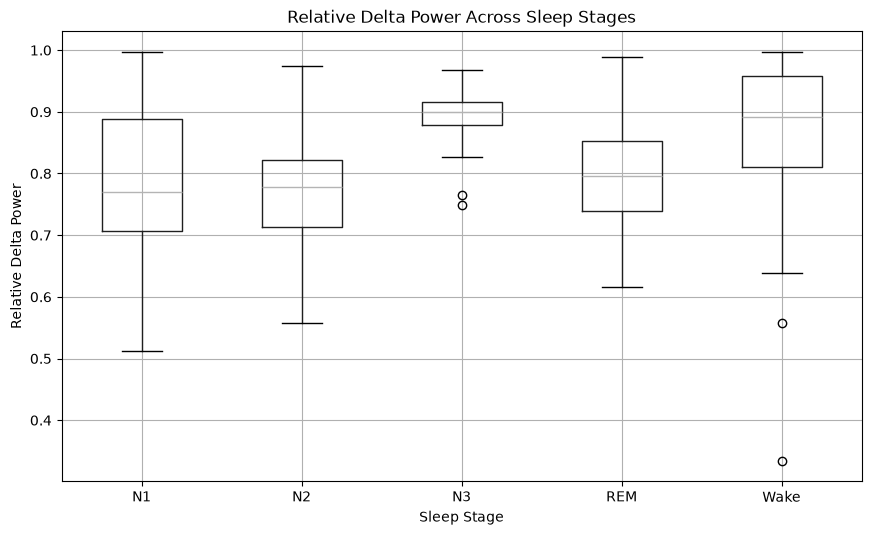

In [16]:
# boxplot of relative delta power (delta/total) grouped by sleep stage
# shows how well delta_rel separates N3 (deep sleep) from other stages
features_df.boxplot(
    column="delta_rel",   # y-axis: relative delta power fraction
    by="stage",           # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("Relative Delta Power Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title above the plot
plt.xlabel("Sleep Stage")
plt.ylabel("Relative Delta Power")

plt.show()

## Viz 6: Relative Theta Power Boxplot

### 💡 Concept
- `theta_rel` = theta/total — the **drowsy and REM rhythm** (4–8 Hz).
- Theta dominates during sleep onset (**N1**) and dreaming (**REM**).
- If N1 and REM boxes overlap → theta alone can't separate them.

### 🔍 What You See in the Plot
| Stage | theta_rel | Interpretation |
|---|---|---|
| **N1** | High | Alpha fades, theta takes over at sleep onset |
| **REM** | High | Theta is the REM background rhythm |
| **N3** | Low | Delta suppresses theta |
| **N2 / Wake** | Medium–Low | Some theta but not dominant |

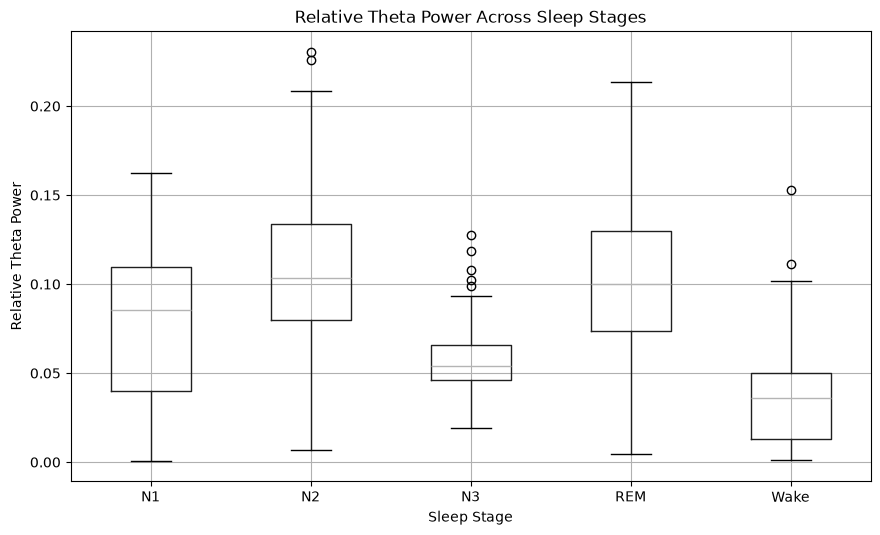

In [17]:
# boxplot of relative theta power (theta/total) grouped by sleep stage
# N1 and REM expected to show higher theta than other stages
features_df.boxplot(
    column="theta_rel",   # y-axis: relative theta power fraction
    by="stage",           # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("Relative Theta Power Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title
plt.xlabel("Sleep Stage")
plt.ylabel("Relative Theta Power")

plt.show()

## Viz 7: Relative Alpha Power Boxplot

### 💡 Concept
- `alpha_rel` = alpha/total (8–13 Hz) — the **relaxed wakefulness signature**.
- Alpha appears when a person closes their eyes while awake and disappears at sleep onset.
- Expected to be clearly highest in **Wake** — clearest frequency-domain Wake separator.

### 🔍 What You See in the Plot
| Stage | alpha_rel | Interpretation |
|---|---|---|
| **Wake** | Highest | Eyes-closed resting state |
| **N1** | Medium | Alpha fades as sleep onset occurs |
| **N2 / N3 / REM** | Low | Alpha suppressed during sleep |

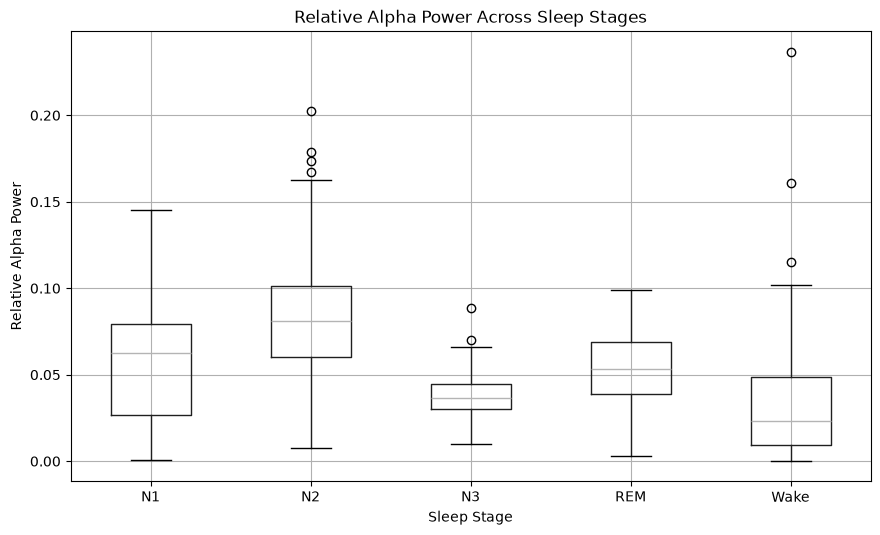

In [18]:
# boxplot of relative alpha power (alpha/total) grouped by sleep stage
# Wake expected to show highest alpha — classic wakefulness discriminator
features_df.boxplot(
    column="alpha_rel",   # y-axis: relative alpha power fraction
    by="stage",           # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("Relative Alpha Power Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title
plt.xlabel("Sleep Stage")
plt.ylabel("Relative Alpha Power")

plt.show()

## Viz 8: Relative Beta Power Boxplot

### 💡 Concept
- `beta_rel` = beta/total (13–30 Hz) — captures **alertness and micro-arousals**.
- Highest in **Wake** (active thinking, arousal). Suppressed during all sleep stages.
- Together, `alpha_rel + beta_rel` form a strong **frequency-domain Wake detector**.

### 🔍 What You See in the Plot
| Stage | beta_rel | Interpretation |
|---|---|---|
| **Wake** | Highest | Active brain — alertness and arousal |
| **N2 / N3** | Low | Beta suppressed in consolidated sleep |
| **REM** | Low–Medium | Some arousal-like beta but less than Wake |

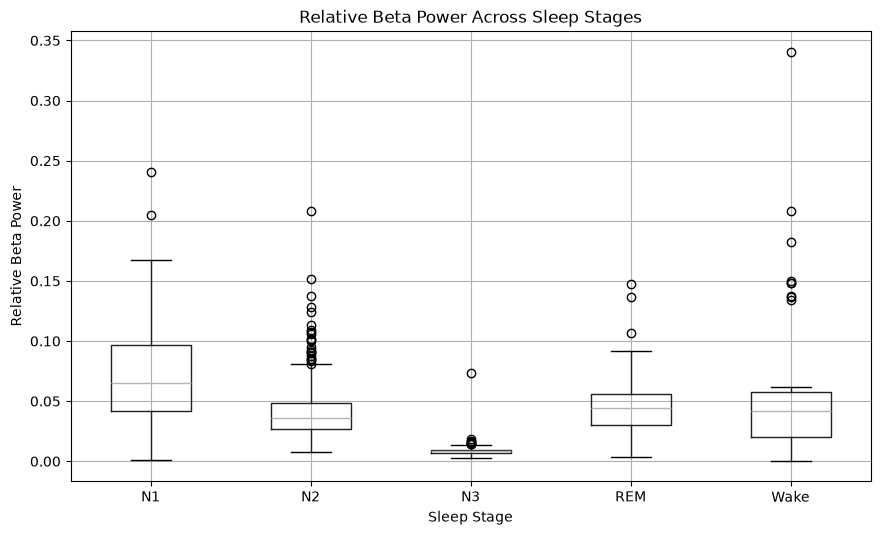

In [19]:
# boxplot of relative beta power (beta/total) grouped by sleep stage
# Wake expected to show highest beta — alertness and arousal marker
features_df.boxplot(
    column="beta_rel",   # y-axis: relative beta power fraction
    by="stage",          # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("Relative Beta Power Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title
plt.xlabel("Sleep Stage")
plt.ylabel("Relative Beta Power")

plt.show()

## Viz 9: EEG Standard Deviation Boxplot

### 💡 Concept
- `std` measures amplitude **variability within a 30-second epoch** — pure time-domain, no FFT.
- Both Wake and N3 show high std, but for different reasons:
  - **Wake** → noisy, irregular, fast activity + muscle/eye artifacts
  - **N3** → large-amplitude slow delta waves (huge but slow swings)

### 🔍 What You See in the Plot
| Stage | std | Reason |
|---|---|---|
| **Wake** | High | Noisy, irregular mixed-frequency |
| **N3** | High | Large-amplitude delta waves |
| **N2** | Medium | Rhythmic spindles — moderate amplitude |
| **REM / N1** | Low–Medium | Quieter signal |

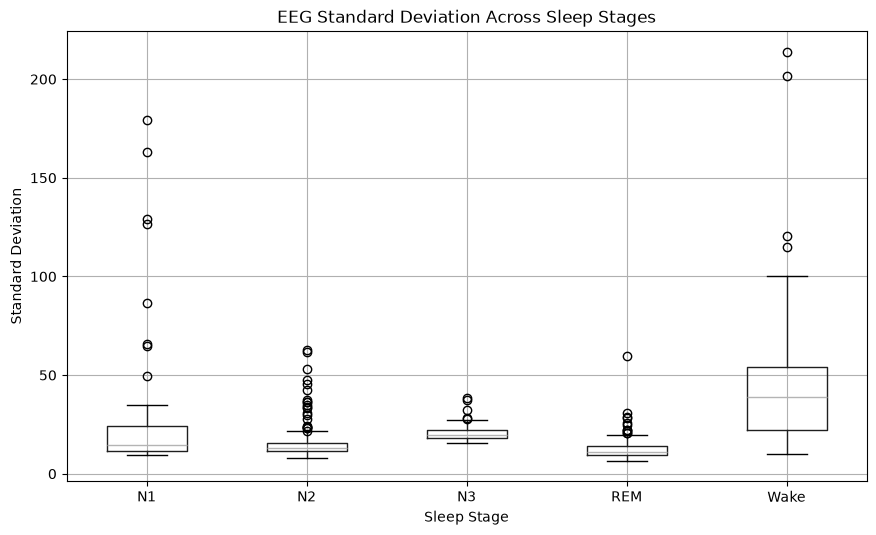

In [20]:
# boxplot of EEG amplitude standard deviation grouped by sleep stage
# key time-domain feature: shows Wake has highest signal variability
features_df.boxplot(
    column="std",   # y-axis: standard deviation of epoch amplitude
    by="stage",     # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("EEG Standard Deviation Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title
plt.xlabel("Sleep Stage")
plt.ylabel("Standard Deviation")

plt.show()

## Viz 10: EEG RMS Boxplot

### 💡 Concept
- **RMS** = total signal energy per epoch: $\text{RMS} = \sqrt{\dfrac{1}{N} \sum_{i=1}^{N} x_i^2}$
- For EEG (mean ≈ 0), **RMS ≈ std** — both measure amplitude spread/energy.
- Together, `std` and `rms` reliably detect Wake — Wake epochs are louder/more energetic than sleep.

### 🔍 What You See in the Plot
| Stage | RMS | Interpretation |
|---|---|---|
| **Wake** | High | High energy — active, noisy brain |
| **N3** | High | Large slow delta waves carry high energy |
| **N2** | Medium | Spindles → moderate periodic energy |
| **REM / N1** | Low–Medium | Quieter signal |

---

## 🔑 Final Observation Carried Forward to ML

```
std + rms    →  separates Wake from all sleep stages       ✅
delta_rel    →  identifies N3 (deep slow-wave sleep)       ✅
theta_rel    →  distinguishes N1 and REM                   ✅
alpha_rel    →  reinforces Wake detection                  ✅
beta_rel     →  additional Wake vs. sleep signal           ✅

Hard problem: N1 vs. REM  (similar theta + similar energy)
```

**Next step:** Use all 15 features as input `X` and train a classifier on `y = label`.

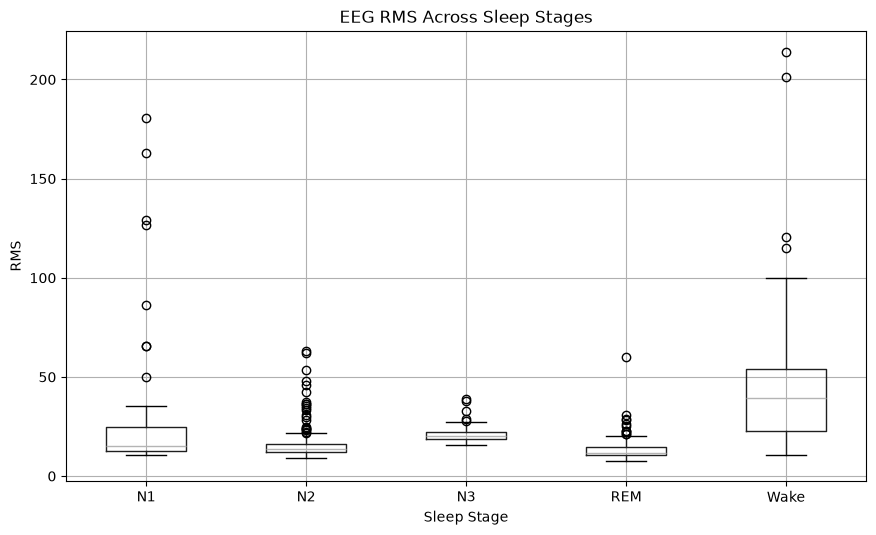

In [21]:
# boxplot of EEG RMS (signal energy) grouped by sleep stage
# RMS ≈ std for zero-mean signals — confirms Wake has highest signal energy
features_df.boxplot(
    column="rms",   # y-axis: root mean square of epoch amplitude
    by="stage",     # x-axis: one box per sleep stage
    figsize=(10, 6)
)

plt.title("EEG RMS Across Sleep Stages")
plt.suptitle("")   # remove pandas auto-generated title
plt.xlabel("Sleep Stage")
plt.ylabel("RMS")

plt.show()

In [23]:
ml_df = features_df[
    [
        "delta",
        "theta",
        "alpha",
        "beta",
        "delta_rel",
        "theta_rel",
        "alpha_rel",
        "beta_rel",
        "std",
        "label",
        "stage"
    ]
].copy()

In [26]:
x = ml_df.drop(columns=["label", "stage"])
y = ml_df["label"]

In [29]:
split=int(len(ml_df)*0.7)

train_df=ml_df.iloc[:split].copy()
test_df=ml_df.iloc[split:].copy()


xtrain=train_df.drop(columns=["label","stage"])
ytrain=train_df["label"]

xtest = test_df.drop(columns=["label", "stage"])
ytest = test_df["label"]

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")

rf_model.fit(xtrain,ytrain)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    ytest,
    ypred,
    labels=[0, 1, 2, 3, 4],
    target_names=["Wake", "N1", "N2", "N3", "REM"],
    zero_division=0
))

              precision    recall  f1-score   support

        Wake       0.57      0.21      0.31        19
          N1       0.31      0.27      0.29        15
          N2       0.81      0.91      0.86       153
          N3       0.00      0.00      0.00         0
         REM       0.84      0.80      0.81        83

    accuracy                           0.79       270
   macro avg       0.51      0.44      0.45       270
weighted avg       0.77      0.79      0.77       270



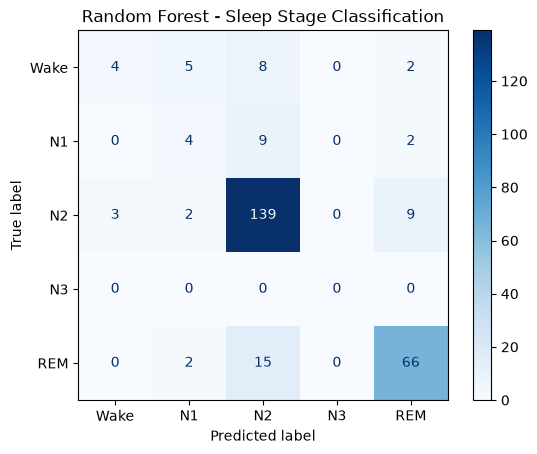

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    ytest,
    ypred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["Wake", "N1", "N2", "N3", "REM"],
    cmap="Blues"
)

plt.title("Random Forest - Sleep Stage Classification")
plt.show()

In [43]:
# important features

importance = pd.DataFrame({
    "Feature": xtrain.columns,
    "Importance": best_rf.feature_importances_*100
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
3,beta,31.501937
7,beta_rel,29.278486
2,alpha,19.097596
1,theta,7.426484
6,alpha_rel,3.406996
8,std,2.862536
5,theta_rel,2.478677
4,delta_rel,2.115853
0,delta,1.831436


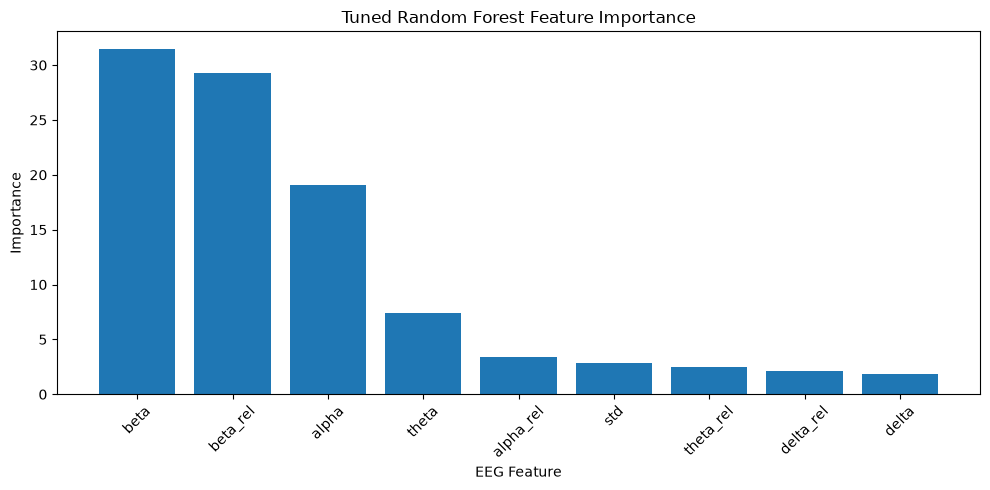

In [44]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("EEG Feature")
plt.ylabel("Importance")
plt.title("Tuned Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [45]:
absolute_features = [
    "delta",
    "theta",
    "alpha",
    "beta"
]
relative_features = [
    "delta_rel",
    "theta_rel",
    "alpha_rel",
    "beta_rel"
]

combined_features = [
    "delta",
    "theta",
    "alpha",
    "beta",
    "delta_rel",
    "theta_rel",
    "alpha_rel",
    "beta_rel",
    "std"
]

In [46]:
from sklearn.metrics import accuracy_score, f1_score

results = {}

for name, features in {
    "Absolute": absolute_features,
    "Relative": relative_features,
    "Combined": combined_features
}.items():

    X_train = train_df[features]
    X_test = test_df[features]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, ytrain)

    pred = model.predict(X_test)

    results[name] = [
        accuracy_score(ytest, pred),
        f1_score(ytest, pred, average="macro")
    ]

In [47]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Macro F1"]
).T

results_df

,Accuracy,Macro F1
Absolute,0.785185,0.590991
Relative,0.729630,0.409450
Combined,0.788889,0.566562


In [48]:
features = ["delta", "theta", "alpha", "beta"]

x = ml_df[features].values
y = ml_df["label"].values

In [49]:
split = int(len(x) * 0.7)

xtrain = x[:split]
xtest = x[split:]

ytrain = y[:split]
ytest = y[split:]

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [51]:
import numpy as np

sequence_length = 5

xtrain_seq = []
ytrain_seq = []

for i in range(len(xtrain) - sequence_length + 1):
    xtrain_seq.append(xtrain[i:i + sequence_length])
    ytrain_seq.append(ytrain[i + sequence_length - 1])

xtest_seq = []
ytest_seq = []

for i in range(len(xtest) - sequence_length + 1):
    xtest_seq.append(xtest[i:i + sequence_length])
    ytest_seq.append(ytest[i + sequence_length - 1])

In [52]:
xtrain_seq = np.array(xtrain_seq)
ytrain_seq = np.array(ytrain_seq)

xtest_seq = np.array(xtest_seq)
ytest_seq = np.array(ytest_seq)

In [57]:
print(xtrain_seq.shape)
print(ytrain_seq.shape)
print(xtest_seq.shape)
print(ytest_seq.shape)

(625, 5, 4)
(625,)
(266, 5, 4)
(266,)


In [60]:
model = Sequential([
    LSTM(64, input_shape=(5, 4)),
    Dense(5, activation="softmax")
])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989 (70.27 KB)

 Trainable params: 17,989 (70.27 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    xtrain_seq,
    ytrain_seq,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[earlystop]
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9480 - loss: 0.1531 - val_accuracy: 0.8960 - val_loss: 0.4021
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9480 - loss: 0.1523 - val_accuracy: 0.8960 - val_loss: 0.4029
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9480 - loss: 0.1514 - val_accuracy: 0.8880 - val_loss: 0.4038
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9480 - loss: 0.1506 - val_accuracy: 0.8880 - val_loss: 0.4046
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1498 - val_accuracy: 0.8880 - val_loss: 0.4055
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1490 - val_accuracy: 0.8880 - val_loss: 0.4064
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1482 - val_accuracy: 0.8960 - val_loss: 0.4073
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1474 - val_accuracy: 0.8960 - val_loss:

In [67]:
ypred = model.predict(xtest_seq)
ypred = np.argmax(ypred, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [68]:
from sklearn.metrics import classification_report

print(classification_report(
    ytest_seq,
    ypred,
    labels=[0, 1, 2, 3, 4],
    target_names=["Wake", "N1", "N2", "N3", "REM"],
    zero_division=0
))

              precision    recall  f1-score   support

        Wake       0.80      0.21      0.33        19
          N1       0.21      0.36      0.26        14
          N2       0.89      0.79      0.83       150
          N3       0.00      0.00      0.00         0
         REM       0.76      0.95      0.84        83

    accuracy                           0.77       266
   macro avg       0.53      0.46      0.46       266
weighted avg       0.81      0.77      0.77       266



In [69]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(ytest_seq, ypred))
print("Macro F1:", f1_score(ytest_seq, ypred, average="macro"))

Accuracy: 0.7744360902255639
Macro F1: 0.5688333189126328


In [70]:
sequence_length = 10

xtrain_seq = []
ytrain_seq = []

for i in range(len(xtrain) - sequence_length + 1):
    xtrain_seq.append(xtrain[i:i+sequence_length])
    ytrain_seq.append(ytrain[i+sequence_length-1])

xtest_seq = []
ytest_seq = []

for i in range(len(xtest) - sequence_length + 1):
    xtest_seq.append(xtest[i:i+sequence_length])
    ytest_seq.append(ytest[i+sequence_length-1])

xtrain_seq = np.array(xtrain_seq)
ytrain_seq = np.array(ytrain_seq)

xtest_seq = np.array(xtest_seq)
ytest_seq = np.array(ytest_seq)

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(10, 4)),
    Dense(5, activation="softmax")
])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
history = model.fit(
    xtrain_seq,
    ytrain_seq,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[earlystop]
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3024 - loss: 1.5760 - val_accuracy: 0.5403 - val_loss: 1.5092
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5544 - loss: 1.4497 - val_accuracy: 0.2661 - val_loss: 1.4390
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6270 - loss: 1.3047 - val_accuracy: 0.2419 - val_loss: 1.3446
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6048 - loss: 1.0884 - val_accuracy: 0.2258 - val_loss: 1.2351
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6472 - loss: 0.8921 - val_accuracy: 0.6210 - val_loss: 0.9647
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7762 - loss: 0.7317 - val_accuracy: 0.7016 - val_loss: 0.8579
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7843 - loss: 0.6162 - val_accuracy: 0.8548 - val_loss: 0.6700
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8206 - loss: 0.5309 - val_accuracy: 0.8548 - val_loss

In [76]:
ypred = model.predict(xtest_seq)
ypred = np.argmax(ypred, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [77]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(ytest_seq, ypred))
print("Macro F1:", f1_score(ytest_seq, ypred, average="macro"))

Accuracy: 0.8122605363984674
Macro F1: 0.5787517545479569


In [78]:
from sklearn.metrics import classification_report

print(classification_report(
    ytest_seq,
    ypred,
    labels=[0, 1, 2, 3, 4],
    target_names=["Wake", "N1", "N2", "N3", "REM"],
    zero_division=0
))

              precision    recall  f1-score   support

        Wake       0.60      0.19      0.29        16
          N1       0.31      0.29      0.30        14
          N2       0.87      0.85      0.86       148
          N3       0.00      0.00      0.00         0
         REM       0.81      0.95      0.87        83

    accuracy                           0.81       261
   macro avg       0.52      0.46      0.46       261
weighted avg       0.80      0.81      0.80       261



In [91]:
from scipy.signal import welch
import numpy as np
import pandas as pd

def extract_eeg_features(raw, subject):

    signal = raw.get_data(
        picks="EEG F4-M1"
    )[0]

    fs = 256
    epoch_size = 30 * fs

    rows = []

    for i in range(0, len(signal) - epoch_size + 1, epoch_size):

        epoch = signal[i:i + epoch_size]

        f, pxx = welch(
            epoch,
            fs=fs,
            nperseg=fs * 2
        )

        power = {}

        for band, (low, high) in bands.items():

            idx = (f >= low) & (f < high)

            power[band] = np.trapz(
                pxx[idx],
                f[idx]
            )

        total = sum(power.values())

        rows.append({
            "subject": subject,
            "epoch": i // epoch_size,

            "delta": power["delta"],
            "theta": power["theta"],
            "alpha": power["alpha"],
            "beta": power["beta"],

            "delta_rel": power["delta"] / total,
            "theta_rel": power["theta"] / total,
            "alpha_rel": power["alpha"] / total,
            "beta_rel": power["beta"] / total,

            "mean": np.mean(epoch),
            "std": np.std(epoch),
            "min": np.min(epoch),
            "max": np.max(epoch),
            "rms": np.sqrt(np.mean(epoch ** 2))
        })

    return pd.DataFrame(rows)

In [115]:
# Rebuild EEG features + labels cleanly

all_eeg = []

for subject in subjects:

    # EEG features
    temp = extract_eeg_features(
        raw_data[subject],
        subject
    )

    # Annotation file
    txt_path = os.path.join(
        annotations_path,
        "auto",
        f"{subject}_EEGarousals_auto.txt"
    )

    ann = pd.read_csv(txt_path)

    ann.columns = ann.columns.str.strip()
    ann["Annotation"] = ann["Annotation"].str.strip()

    # Keep only sleep stages
    ann = ann[
        ann["Annotation"].str.startswith("Sleep stage")
    ].copy()

    # Convert recording time to 30-sec epoch
    ann["epoch"] = (
        ann["Recording onset"] / 30
    ).round().astype(int)

    # Stage name
    ann["stage"] = ann["Annotation"].str.replace(
        "Sleep stage ",
        "",
        regex=False
    )

    # Numeric label
    ann["label"] = ann["Annotation"].map({
        "Sleep stage W": 0,
        "Sleep stage N1": 1,
        "Sleep stage N2": 2,
        "Sleep stage N3": 3,
        "Sleep stage R": 4
    })

    labels = ann[
        ["epoch", "stage", "label"]
    ]

    # Merge this subject's EEG with this subject's labels
    temp = temp.merge(
        labels,
        on="epoch",
        how="inner"
    )

    all_eeg.append(temp)

    print(subject, temp.shape)

# Combine subjects
ml_df = pd.concat(
    all_eeg,
    ignore_index=True
)

print("Final shape:", ml_df.shape)

SN1 (865, 17)
SN2 (867, 17)
SN3 (975, 17)
SN4 (982, 17)
SN5 (1056, 17)
Final shape: (4745, 17)


In [117]:
print(
    ml_df.groupby(
        ["subject", "stage"]
    ).size()
)

subject  stage
SN1      N1        72
         N2       244
         N3       187
         R         96
         W        266
SN2      N1        53
         N2       299
         N3       177
         R        127
         W        211
SN3      N1        68
         N2       541
         N3        99
         R        235
         W         32
SN4      N1        97
         N2       329
         N3       263
         R        189
         W        104
SN5      N1        68
         N2       492
         N3       208
         R        105
         W        183
dtype: int64


In [121]:
print(ml_df["label"].value_counts().sort_index())

label
0     796
1     358
2    1905
3     934
4     752
Name: count, dtype: int64


In [123]:
X_train = ml_df[
    ml_df["subject"] != "SN5"
][features]

y_train = ml_df[
    ml_df["subject"] != "SN5"
]["label"]

X_test = ml_df[
    ml_df["subject"] == "SN5"
][features]

y_test = ml_df[
    ml_df["subject"] == "SN5"
]["label"]

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

features = ["delta", "theta", "alpha", "beta"]

train_df = ml_df[ml_df["subject"] != "SN5"]
test_df = ml_df[ml_df["subject"] == "SN5"]

X_train = train_df[features]
y_train = train_df["label"]

X_test = test_df[features]
y_test = test_df["label"]

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

ypred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, ypred_rf))
print("Macro F1:", f1_score(y_test, ypred_rf, average="macro"))

print(classification_report(
    y_test,
    ypred_rf,
    labels=[0, 1, 2, 3, 4],
    target_names=["Wake", "N1", "N2", "N3", "REM"],
    zero_division=0
))

Accuracy: 0.6287878787878788
Macro F1: 0.5240893011282659
              precision    recall  f1-score   support

        Wake       0.56      0.76      0.65       183
          N1       0.14      0.26      0.18        68
          N2       0.72      0.66      0.69       492
          N3       0.88      0.76      0.82       208
         REM       0.49      0.20      0.28       105

    accuracy                           0.63      1056
   macro avg       0.56      0.53      0.52      1056
weighted avg       0.66      0.63      0.64      1056



In [126]:
features = ["delta", "theta", "alpha", "beta"]

train_subjects = ["SN1", "SN2", "SN3", "SN4"]
test_subject = "SN5"

sequence_length = 10

xtrain_seq = []
ytrain_seq = []

for subject in train_subjects:

    df = ml_df[ml_df["subject"] == subject].copy()
    df = df.sort_values("epoch")

    X = df[features].values
    y = df["label"].values

    for i in range(len(X) - sequence_length + 1):

        xtrain_seq.append(
            X[i:i + sequence_length]
        )

        ytrain_seq.append(
            y[i + sequence_length - 1]
        )

In [127]:
xtest_seq = []
ytest_seq = []

df = ml_df[
    ml_df["subject"] == test_subject
].copy()

df = df.sort_values("epoch")

X = df[features].values
y = df["label"].values

for i in range(len(X) - sequence_length + 1):

    xtest_seq.append(
        X[i:i + sequence_length]
    )

    ytest_seq.append(
        y[i + sequence_length - 1]
    )

In [128]:
xtrain_seq = np.array(xtrain_seq)
ytrain_seq = np.array(ytrain_seq)

xtest_seq = np.array(xtest_seq)
ytest_seq = np.array(ytest_seq)

print(xtrain_seq.shape)
print(xtest_seq.shape)

(3653, 10, 4)
(1047, 10, 4)


In [153]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

sequence_lengths = [3, 5,7, 10, 12,15, 18,20,30]

results = []

for seq_len in sequence_lengths:

    xtrain = []
    ytrain = []

    # Create training sequences
    for subject in ["SN1", "SN2", "SN3", "SN4"]:

        df = train_df[
            train_df["subject"] == subject
        ].sort_values("epoch")

        X = df[features].values
        y = df["label"].values

        for i in range(len(X) - seq_len + 1):
            xtrain.append(X[i:i + seq_len])
            ytrain.append(y[i + seq_len - 1])

    # Create test sequences
    xtest = []
    ytest = []

    df = test_df.sort_values("epoch")

    X = df[features].values
    y = df["label"].values

    for i in range(len(X) - seq_len + 1):
        xtest.append(X[i:i + seq_len])
        ytest.append(y[i + seq_len - 1])

    xtrain = np.array(xtrain)
    ytrain = np.array(ytrain)

    xtest = np.array(xtest)
    ytest = np.array(ytest)

    # LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, 4)),
        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        xtrain,
        ytrain,
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        shuffle=False,
        verbose=0
    )

    # Prediction
    pred = np.argmax(
        model.predict(xtest, verbose=0),
        axis=1
    )

    accuracy = accuracy_score(ytest, pred)
    macro_f1 = f1_score(
        ytest,
        pred,
        average="macro"
    )

    results.append([
        seq_len,
        accuracy,
        macro_f1
    ])

    print(
        "Sequence:", seq_len,
        "Accuracy:", round(accuracy, 3),
        "Macro F1:", round(macro_f1, 3)
    )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 3 Accuracy: 0.554 Macro F1: 0.4


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 5 Accuracy: 0.569 Macro F1: 0.412


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 7 Accuracy: 0.59 Macro F1: 0.41


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 10 Accuracy: 0.561 Macro F1: 0.392


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 12 Accuracy: 0.58 Macro F1: 0.382


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 15 Accuracy: 0.587 Macro F1: 0.386


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 18 Accuracy: 0.518 Macro F1: 0.349


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 20 Accuracy: 0.521 Macro F1: 0.352


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sequence: 30 Accuracy: 0.565 Macro F1: 0.441


In [154]:
results_df = pd.DataFrame(
    results,
    columns=["Sequence Length", "Accuracy", "Macro F1"]
)

print(results_df)

   Sequence Length  Accuracy  Macro F1
0                3  0.554080  0.400080
1                5  0.569392  0.412112
2                7  0.589524  0.410341
3               10  0.560649  0.391708
4               12  0.579904  0.381995
5               15  0.587332  0.385708
6               18  0.517806  0.349308
7               20  0.520733  0.352252
8               30  0.564752  0.440936
